In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/dhang/Downloads/ai_assisted_detection_training_data_5000_hard.csv")

In [3]:
df.head()

,time_to_first_submission,keystroke_speed_avg,keystroke_speed_variance,deletion_ratio,pasted_code_ratio,external_source_similarity,complexity_vs_optimal,deviation_from_player_baseline,success_rate,efficiency_vs_player_avg,label
0,25.492642,61.000775,0.100000,0.233227,0.554277,0.746839,1.107636,0.714864,0.778201,1.442379,ai_assisted
1,70.310858,44.042696,10.827812,0.249444,0.000000,0.070719,1.261554,0.336201,0.416838,1.027353,legitimate
2,22.822971,20.592675,12.645870,0.265918,0.000000,0.285322,1.166245,0.039879,1.000000,1.021096,legitimate
3,35.360061,62.397630,0.100000,0.122663,0.350498,0.699120,0.820601,0.572802,0.830820,2.121969,ai_assisted
4,33.066017,39.715617,6.915889,0.117576,0.344575,0.516670,1.045150,0.841532,0.502402,1.122017,ai_assisted


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time_to_first_submission        5000 non-null   float64
 1   keystroke_speed_avg             5000 non-null   float64
 2   keystroke_speed_variance        5000 non-null   float64
 3   deletion_ratio                  5000 non-null   float64
 4   pasted_code_ratio               5000 non-null   float64
 5   external_source_similarity      5000 non-null   float64
 6   complexity_vs_optimal           5000 non-null   float64
 7   deviation_from_player_baseline  5000 non-null   float64
 8   success_rate                    5000 non-null   float64
 9   efficiency_vs_player_avg        5000 non-null   float64
 10  label                           5000 non-null   object 
dtypes: float64(10), object(1)
memory usage: 429.8+ KB


In [4]:
from xgboost import XGBClassifier

In [5]:
model2 = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.7,
    reg_lambda=1.2,
    gamma=1.5,
    objective='multi:softprob'
)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['label'])

In [8]:
X = df.drop("label", axis=1)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)

In [10]:
y

array([0, 1, 1, ..., 0, 2, 0])

In [11]:
X_train.shape

(4750, 10)

In [12]:
y_train.shape

(4750,)

In [13]:
model2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model2.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        90
           1       0.83      0.82      0.83        97
           2       0.88      0.89      0.88        63

    accuracy                           0.82       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.82      0.82      0.82       250

[[69 15  6]
 [15 80  2]
 [ 6  1 56]]


In [15]:
probs = model2.predict_proba(X_test)

print(probs[0])

[0.12759718 0.85037506 0.0220278 ]


In [16]:
model2.score(X_test, y_test)

0.82

In [18]:
from sklearn.model_selection import StratifiedKFold , cross_val_score
skf = StratifiedKFold(n_splits=5)

scores = cross_val_score(model2, X, y, cv=skf, scoring='accuracy')

print("Mean accuracy:", scores.mean())

Mean accuracy: 0.8244


In [17]:
import joblib

joblib.dump(model2 , 'cheat_detection_model.pkl')
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [25]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.001,
    loss_function='MultiClass'
)

In [26]:
catboost_model.fit(X_train , y_train)

0:	learn: 1.0977357	total: 51.1ms	remaining: 51.1s
1:	learn: 1.0968881	total: 95.5ms	remaining: 47.7s
2:	learn: 1.0959744	total: 134ms	remaining: 44.6s
3:	learn: 1.0951439	total: 173ms	remaining: 43.1s
4:	learn: 1.0942362	total: 206ms	remaining: 41s
5:	learn: 1.0933874	total: 234ms	remaining: 38.7s
6:	learn: 1.0925771	total: 284ms	remaining: 40.3s
7:	learn: 1.0917345	total: 350ms	remaining: 43.4s
8:	learn: 1.0908933	total: 375ms	remaining: 41.3s
9:	learn: 1.0900245	total: 404ms	remaining: 40s
10:	learn: 1.0892185	total: 426ms	remaining: 38.3s
11:	learn: 1.0884028	total: 452ms	remaining: 37.2s
12:	learn: 1.0876473	total: 478ms	remaining: 36.3s
13:	learn: 1.0867678	total: 504ms	remaining: 35.5s
14:	learn: 1.0859907	total: 532ms	remaining: 34.9s
15:	learn: 1.0851736	total: 555ms	remaining: 34.1s
16:	learn: 1.0842973	total: 579ms	remaining: 33.5s
17:	learn: 1.0834375	total: 603ms	remaining: 32.9s
18:	learn: 1.0826072	total: 628ms	remaining: 32.4s
19:	learn: 1.0817532	total: 650ms	remaining

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = catboost_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        90
           1       0.83      0.80      0.82        97
           2       0.89      0.86      0.87        63

    accuracy                           0.81       250
   macro avg       0.82      0.81      0.81       250
weighted avg       0.81      0.81      0.81       250

[[70 15  5]
 [17 78  2]
 [ 8  1 54]]


In [87]:
probs = catboost_model.predict_proba(X_test)

print(probs[0])

[0.14063368 0.83450908 0.02485724]


In [ ]:
import joblib

joblib.dump(model2, "cheat_detector.pkl")
joblib.dump(le, "label_encoder.pkl")

<Axes: >

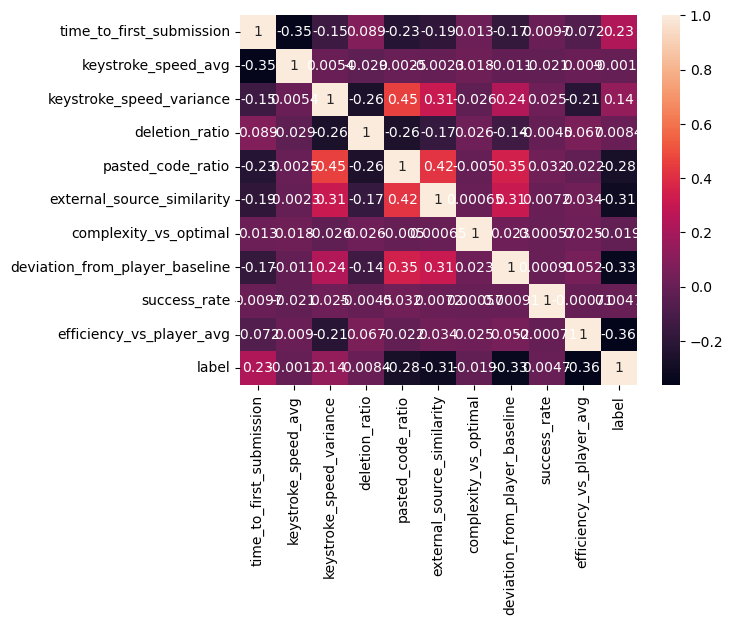

In [62]:
import seaborn as sns
df_temp = df.copy()
df_temp['label'] = df_temp['label'].map({"ai_assisted": 0, "pasted": 1, "legitimate": 2})
cors = df_temp.corr()
sns.heatmap(cors, annot=True)

In [63]:
df_temp.corr()

,time_to_first_submission,keystroke_speed_avg,keystroke_speed_variance,deletion_ratio,pasted_code_ratio,external_source_similarity,complexity_vs_optimal,deviation_from_player_baseline,success_rate,efficiency_vs_player_avg,label
time_to_first_submission,1.000000,-0.347844,-0.145274,0.088979,-0.225323,-0.190559,0.013112,-0.174121,0.009685,-0.072013,0.228898
keystroke_speed_avg,-0.347844,1.000000,0.005355,-0.029147,0.002485,-0.002289,0.018258,-0.011264,-0.021201,0.009044,-0.001238
keystroke_speed_variance,-0.145274,0.005355,1.000000,-0.264372,0.453922,0.308754,-0.025985,0.235052,0.024560,-0.214232,0.140988
deletion_ratio,0.088979,-0.029147,-0.264372,1.000000,-0.258075,-0.169138,0.025815,-0.137163,-0.004508,0.066919,0.008412
pasted_code_ratio,-0.225323,0.002485,0.453922,-0.258075,1.000000,0.423970,-0.005001,0.346435,0.032461,-0.021599,-0.276208
external_source_similarity,-0.190559,-0.002289,0.308754,-0.169138,0.423970,1.000000,0.000653,0.310290,0.007173,0.034398,-0.312255
complexity_vs_optimal,0.013112,0.018258,-0.025985,0.025815,-0.005001,0.000653,1.000000,0.023291,0.000574,0.025147,-0.019120
deviation_from_player_baseline,-0.174121,-0.011264,0.235052,-0.137163,0.346435,0.310290,0.023291,1.000000,0.000906,0.051896,-0.334105
success_rate,0.009685,-0.021201,0.024560,-0.004508,0.032461,0.007173,0.000574,0.000906,1.000000,-0.000713,0.004689
efficiency_vs_player_avg,-0.072013,0.009044,-0.214232,0.066919,-0.021599,0.034398,0.025147,0.051896,-0.000713,1.000000,-0.362331


In [16]:
df = pd.read_csv("/content/ai_assisted_detection_training_data_5000_hard.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/ai_assisted_detection_training_data_5000_hard.csv'

In [ ]:
df

,time_to_first_submission,keystroke_speed_avg,keystroke_speed_variance,deletion_ratio,pasted_code_ratio,external_source_similarity,complexity_vs_optimal,deviation_from_player_baseline,success_rate,efficiency_vs_player_avg,label
0,25.492642,61.000775,0.100000,0.233227,0.554277,0.746839,1.107636,0.714864,0.778201,1.442379,ai_assisted
1,70.310858,44.042696,10.827812,0.249444,0.000000,0.070719,1.261554,0.336201,0.416838,1.027353,legitimate
2,22.822971,20.592675,12.645870,0.265918,0.000000,0.285322,1.166245,0.039879,1.000000,1.021096,legitimate
3,35.360061,62.397630,0.100000,0.122663,0.350498,0.699120,0.820601,0.572802,0.830820,2.121969,ai_assisted
4,33.066017,39.715617,6.915889,0.117576,0.344575,0.516670,1.045150,0.841532,0.502402,1.122017,ai_assisted
...,...,...,...,...,...,...,...,...,...,...,...
4995,51.552188,42.714800,6.043770,0.136122,0.706745,0.800986,0.827564,0.625578,0.937601,1.377369,ai_assisted
4996,35.903871,34.676094,6.855366,0.134648,0.000000,0.299822,1.023778,0.207998,0.963282,1.305171,ai_assisted
4997,41.336768,36.620000,4.179791,0.282975,0.439348,0.547231,0.874635,0.573174,0.205335,2.275351,ai_assisted
4998,22.670205,63.694632,15.763952,0.000000,0.306445,0.755637,1.328615,0.717745,0.731605,1.255530,pasted


In [ ]:
X, y = df[df.columns.drop('label')], df['label']
y = y.map({
    "ai_assisted": 0,
    "pasted": 1,
    "legitimate": 2
})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model_0 = XGBClassifier()
model_0.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
model_0.score(X_test, y_test)

0.804

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

In [ ]:
grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=3)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]})

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

## Initialize and Fit GridSearchCV

### Subtask:
Initialize `GridSearchCV` with the `XGBClassifier`, the expanded `param_grid`, and fit it to the training data (`X_train`, `y_train`).

In [ ]:
grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=3)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 0.8, 0.9]})

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test Score:", test_score)

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best Score: 0.8259949170201096
Test Score: 0.836
